# Data from 23rd to 25th of February, evaporating at 30K

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import pandas as pd

from scipy.optimize import curve_fit

import matplotlib.dates as mdates


In [2]:
scaler1 = r"C:\Users\keert\Master Thesis February\Moderator lifetime\regrow_30K\scaler"
scaler2 = r"C:\Users\keert\Master Thesis February\Moderator lifetime\regrow_30K\scaler_cont"

data1 = np.loadtxt(scaler1,dtype=str,usecols=(0,1,3))
data2 = np.loadtxt(scaler2,dtype=str,usecols=(0,1,3))

data = np.concatenate((data1,data2),axis=0)



In [3]:
print(data.shape)
n_data = data.shape[0]

(160085, 3)


In [4]:
timestamps = pd.to_datetime(data[:, 0] + " " + data[:, 1])

hours_since_start = (timestamps - timestamps[0]) / pd.Timedelta(hours=1)

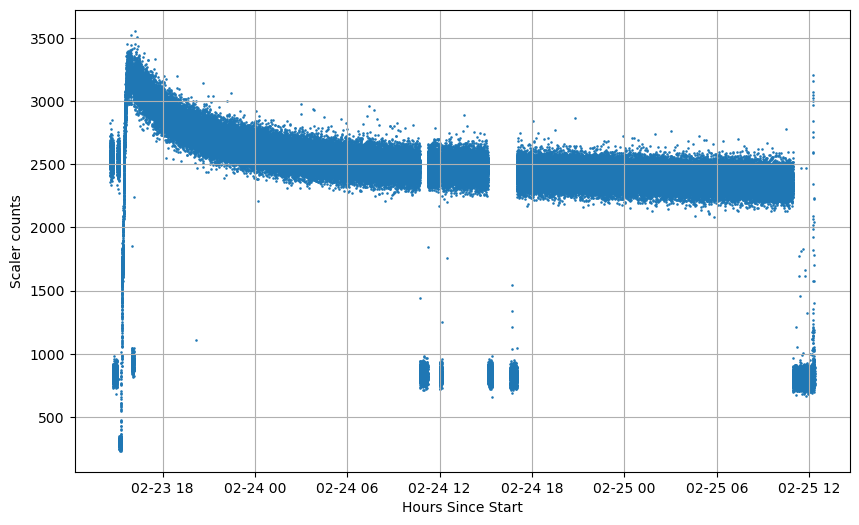

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(timestamps, data[:, 2].astype(float), s=0.7, label='Scaler Value')
plt.xlabel('Hours Since Start')
plt.ylabel("Scaler counts")
plt.grid(True)

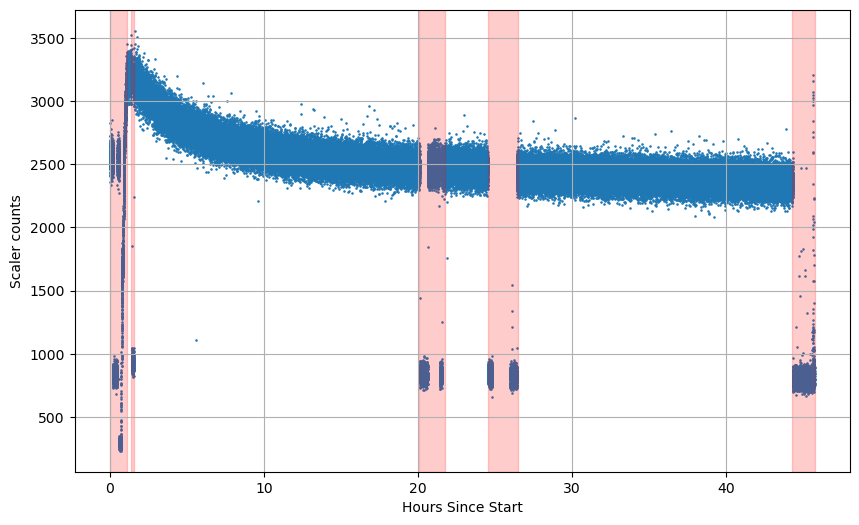

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(hours_since_start, data[:, 2].astype(float), s=0.7, label='Scaler Value')
plt.xlabel('Hours Since Start')
plt.ylabel("Scaler counts")
plt.grid(True)
#plt.xlim(left=0,right=5)

plt.axvspan(hours_since_start[0],hours_since_start[4000],alpha=0.2,color="red")
plt.axvspan(hours_since_start[5000],hours_since_start[5700],alpha=0.2,color="red")
plt.axvspan(hours_since_start[88000],hours_since_start[90900],alpha=0.2,color="red")
plt.axvspan(hours_since_start[72000],hours_since_start[78000],alpha=0.2,color="red")
plt.axvspan(hours_since_start[n_data-5200],hours_since_start[n_data-1],alpha=0.2,color="red")

In [7]:
intervals = [(0,4000),(5000,5700),(72000,78000),(88000,90900),(n_data-5200,n_data-1)]

N = len(hours_since_start)
mask = np.ones(N, dtype=bool)

for start, end in intervals:
    mask[start:end+1] = False

In [8]:
t_clean = hours_since_start[mask]
counts_clean = data[:, 2].astype(float)[mask]


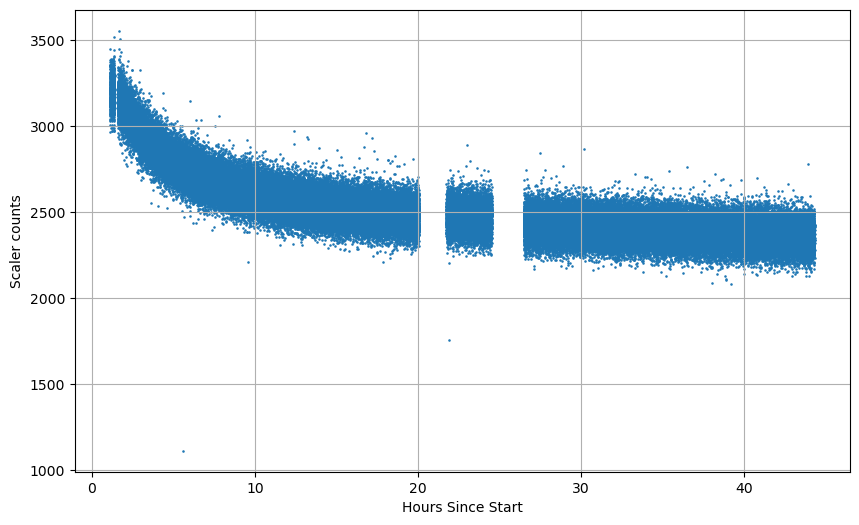

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(t_clean,counts_clean, s=0.7, label='Scaler Value')
plt.xlabel('Hours Since Start')
plt.ylabel("Scaler counts")
plt.grid(True)


In [10]:
def model(t, A1, tau1, A2, tau2,B):
    return A1*np.exp(-t/tau1) + A2*np.exp(-t/tau2) +B

In [11]:
def model_single_exp(t, A, tau, B):
    return A*np.exp(-t/tau) + B

In [12]:
def model_single_exp_linear(t, A, tau, m, B):
    return A * np.exp(-t / tau) + m * t + B

In [13]:
sigma = np.sqrt(counts_clean)  

p0 = [1e6, 100, 1e6, 100, 1e6]  

bounds = ([0, 0, 0, 0, 0],           
          [np.inf, np.inf, np.inf, np.inf, np.inf])  


popt, pcov = curve_fit(model, t_clean,counts_clean , p0=p0,sigma=sigma, bounds=bounds, absolute_sigma=True)

print("Best-fit params:", popt)
print("Errors:", np.sqrt(np.diag(pcov)))

Best-fit params: [ 825.80935256    3.52545311  437.62389507   40.09220542 2211.71202235]
Errors: [2.68586445 0.02424496 4.95567739 1.49951051 7.89625232]


In [14]:
popt, pcov, infodict, mesg, ier = curve_fit(model, t_clean, counts_clean, 
                                             p0=p0, sigma=sigma, bounds=bounds, 
                                             absolute_sigma=True, full_output=True)

print("Best-fit params:", popt)
print("Errors:", np.sqrt(np.diag(pcov)))
print("\nConvergence info:")
print(f"Success: {ier in [1, 2, 3, 4]}")  # ier=1-4 means success
print(f"Message: {mesg}")
print(f"Number of function calls: {infodict['nfev']}")

# Calculate reduced chi-squared
residuals = (counts_clean - model(t_clean, *popt)) / sigma
chi_squared = np.sum(residuals**2)
dof = len(counts_clean) - len(popt)
reduced_chi_sq = chi_squared / dof

print(f"\nChi-squared: {chi_squared:.4f}")
print(f"Reduced chi-squared: {reduced_chi_sq:.4f}")
print(f"DOF: {dof}")

Best-fit params: [ 825.80935256    3.52545311  437.62389507   40.09220542 2211.71202235]
Errors: [2.68586445 0.02424496 4.95567739 1.49951051 7.89625232]

Convergence info:
Success: True
Message: `ftol` termination condition is satisfied.
Number of function calls: 38

Chi-squared: 279697.4590
Reduced chi-squared: 1.9798
DOF: 141276


Text(0, 0.5, 'Normalized residuals')

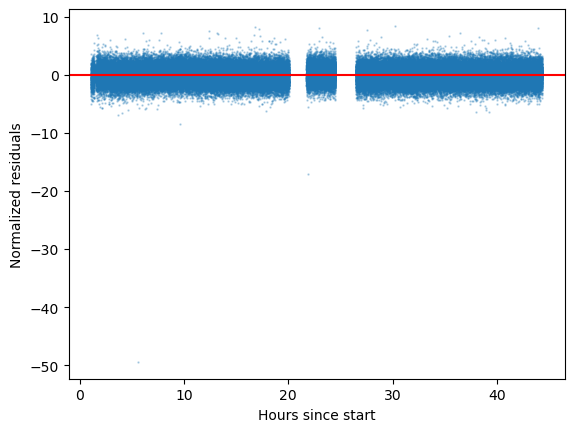

In [15]:
residuals = counts_clean - model(t_clean, *popt)
normalized_residuals = residuals / np.sqrt(counts_clean)

plt.figure()
plt.scatter(t_clean, normalized_residuals, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')

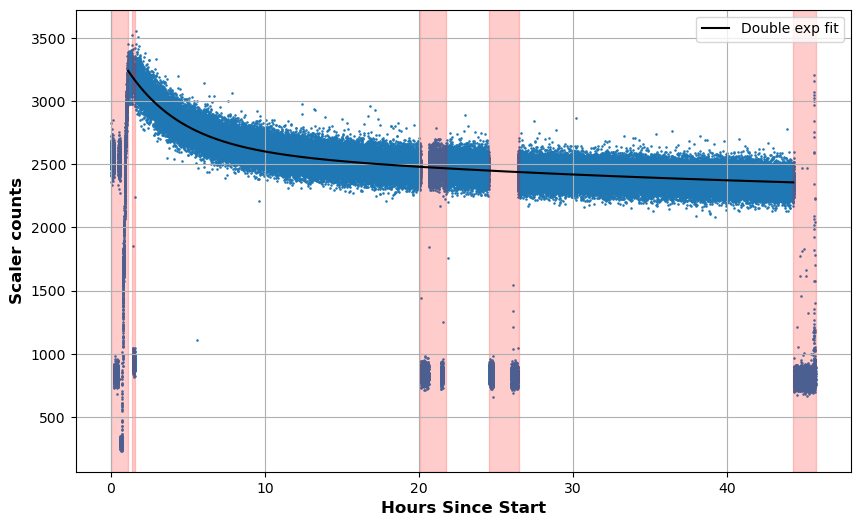

In [16]:
t_fit = np.linspace(t_clean.min(), t_clean.max(), 2000)

y_fit = model(t_fit, *popt)

plt.figure(figsize=(10,6))
    
plt.plot(t_fit, y_fit, label="Double exp fit",color="k")

plt.xlabel("Hours Since Start",fontweight="bold",fontsize="large")
plt.ylabel("Scaler counts",fontweight="bold",fontsize="large")
plt.grid(True)

plt.scatter(hours_since_start, data[:, 2].astype(float), s=0.7)

plt.axvspan(hours_since_start[0],hours_since_start[4000],alpha=0.2,color="red")
plt.axvspan(hours_since_start[5000],hours_since_start[5700],alpha=0.2,color="red")
plt.axvspan(hours_since_start[88000],hours_since_start[90900],alpha=0.2,color="red")
plt.axvspan(hours_since_start[72000],hours_since_start[78000],alpha=0.2,color="red")
plt.axvspan(hours_since_start[n_data-5200],hours_since_start[n_data-1],alpha=0.2,color="red")

plt.legend()


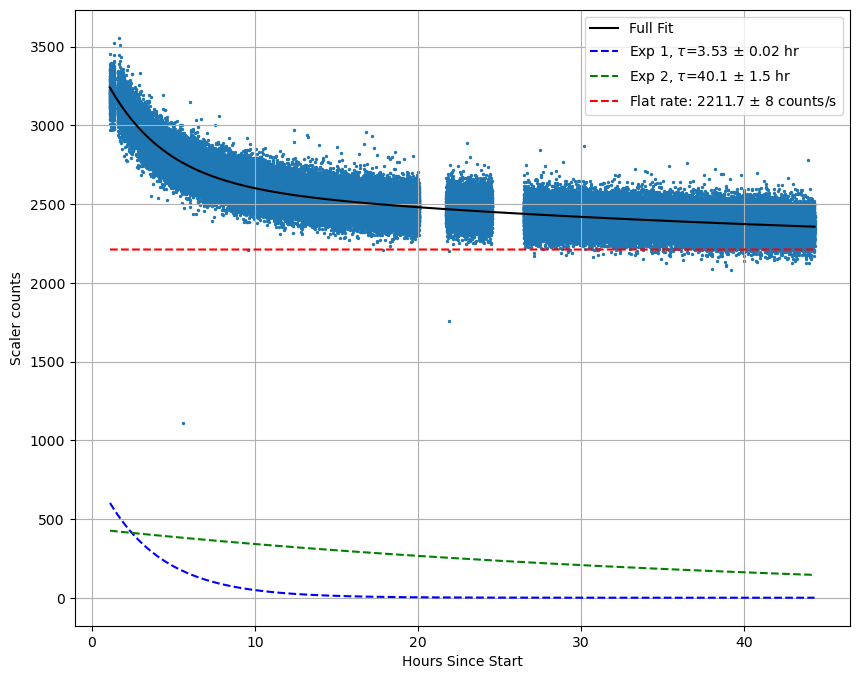

In [17]:
A1, tau1, A2, tau2, B = popt

y_exp1 = A1 * np.exp(-t_fit/tau1)
y_exp2 = A2 * np.exp(-t_fit/tau2)
y_bg   = np.full_like(t_fit, B)

plt.figure(figsize=(10,8))

# data
plt.scatter(t_clean, counts_clean, s=2)

# full fit
plt.plot(t_fit, y_fit, color='black', label='Full Fit')

# individual components
plt.plot(t_fit, y_exp1, '--', color='blue', label=rf'Exp 1, $\tau$={tau1:.2f} $\pm$ {np.sqrt(np.diag(pcov))[1]:.2f} hr')
plt.plot(t_fit, y_exp2, '--', color='green', label=rf'Exp 2, $\tau$={tau2:.1f} $\pm$ {np.sqrt(np.diag(pcov))[3]:.1f} hr')
plt.plot(t_fit, y_bg, '--', color='red', label=rf'Flat rate: {B:.1f} $\pm$ {np.sqrt(np.diag(pcov))[4]:.0f} counts/s')

plt.xlabel("Hours Since Start")
plt.ylabel("Scaler counts")
plt.legend()
plt.grid(True)


In [18]:
p0_sing = [800, 30, 800]  

bounds_sing = [0, 0, 0], [np.inf, np.inf, np.inf]

popt_sing, pcov_sing = curve_fit(model_single_exp, t_clean,counts_clean , p0=p0_sing,sigma=sigma, absolute_sigma=True)

print("Best-fit params:", popt_sing)
print("Errors:", np.sqrt(np.diag(pcov_sing)))


Best-fit params: [ 856.3880063     7.45250999 2391.70450599]
Errors: [0.95649303 0.01291574 0.22181928]


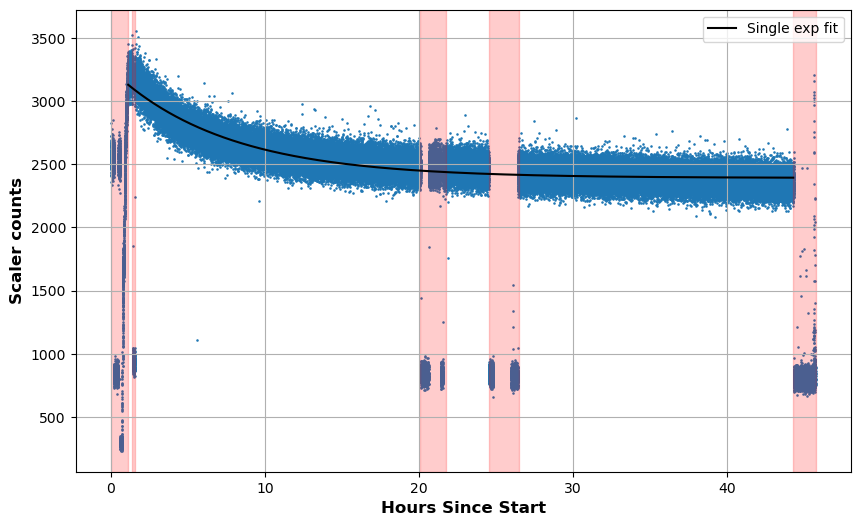

In [19]:
t_fit = np.linspace(t_clean.min(), t_clean.max(), 2000)

y_fit_sing = model_single_exp(t_fit, *popt_sing)

plt.figure(figsize=(10,6))
    
plt.plot(t_fit, y_fit_sing, label="Single exp fit", color="k")

plt.xlabel("Hours Since Start", fontweight="bold", fontsize="large")
plt.ylabel("Scaler counts", fontweight="bold", fontsize="large")
plt.grid(True)

plt.scatter(hours_since_start, data[:, 2].astype(float), s=0.7)

plt.axvspan(hours_since_start[0],      hours_since_start[4000],      alpha=0.2, color="red")
plt.axvspan(hours_since_start[5000],   hours_since_start[5700],      alpha=0.2, color="red")
plt.axvspan(hours_since_start[72000],  hours_since_start[78000],     alpha=0.2, color="red")
plt.axvspan(hours_since_start[88000],  hours_since_start[90900],     alpha=0.2, color="red")
plt.axvspan(hours_since_start[n_data-5200], hours_since_start[n_data-1], alpha=0.2, color="red")

plt.legend()

In [20]:
# Calculate reduced chi-squared
residuals_sing = (counts_clean - model_single_exp(t_clean, *popt_sing)) / sigma
chi_squared_sing = np.sum(residuals_sing**2)
dof_sing = len(counts_clean) - len(popt_sing)
reduced_chi_sq_sign = chi_squared_sing / dof_sing

print(f"\nChi-squared: {chi_squared_sing:.4f}")
reduced_chi_sq_sing = chi_squared_sing / dof_sing
print(f"Reduced chi-squared: {reduced_chi_sq_sing:.4f}")


Chi-squared: 310769.0138
Reduced chi-squared: 2.1997


Text(0, 0.5, 'Normalized residuals')

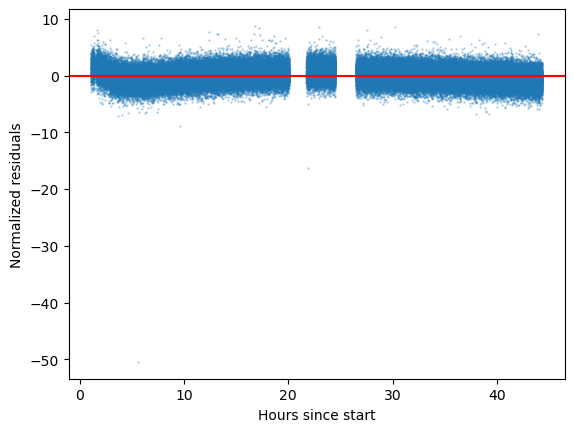

In [21]:
residuals_sing = counts_clean - model_single_exp(t_clean, *popt_sing)
normalized_residuals_sing = residuals_sing / np.sqrt(counts_clean)

plt.figure()
plt.scatter(t_clean, normalized_residuals_sing, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')

In [22]:
p0_linear = [1e6, 100, -1, 1e4]

bounds_linear = ([0, 0, -np.inf, 0],
                 [np.inf, np.inf, 0, np.inf])

sigma = np.sqrt(counts_clean)

popt_linear, pcov_linear, infodict_linear, mesg_linear, ier_linear = curve_fit(
    model_single_exp_linear, t_clean, counts_clean,
    p0=p0_linear, sigma=sigma, bounds=bounds_linear,
    absolute_sigma=True, full_output=True)

print("Best-fit params:", popt_linear)
print("Errors:", np.sqrt(np.diag(pcov_linear)))
print(f"Success: {ier_linear in [1, 2, 3, 4]}")
print(f"Message: {mesg_linear}")


Best-fit params: [ 863.24288088    4.04675865   -5.14643558 2577.00867002]
Errors: [1.69968546 0.01341425 0.02099942 0.68984347]
Success: True
Message: `ftol` termination condition is satisfied.


In [23]:
residuals_linear = (counts_clean - model_single_exp_linear(t_clean, *popt_linear)) / sigma
chi_squared_linear = np.sum(residuals_linear**2)
dof_linear = len(counts_clean) - len(popt_linear)
reduced_chi_sq_linear = chi_squared_linear / dof_linear

print(f"\nChi-squared: {chi_squared_linear:.4f}")
print(f"Reduced chi-squared: {reduced_chi_sq_linear:.4f}")
print(f"DOF: {dof_linear}")




Chi-squared: 280290.7794
Reduced chi-squared: 1.9840
DOF: 141277


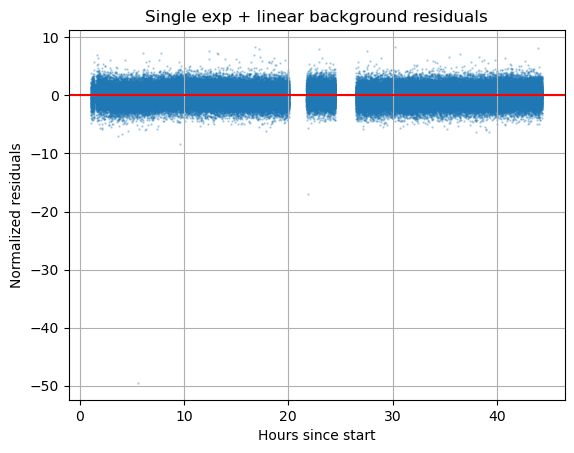

In [24]:
residuals_norm_linear = (counts_clean - model_single_exp_linear(t_clean, *popt_linear)) / np.sqrt(counts_clean)

plt.figure()
plt.scatter(t_clean, residuals_norm_linear, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')
plt.title('Single exp + linear background residuals')
plt.grid(True)

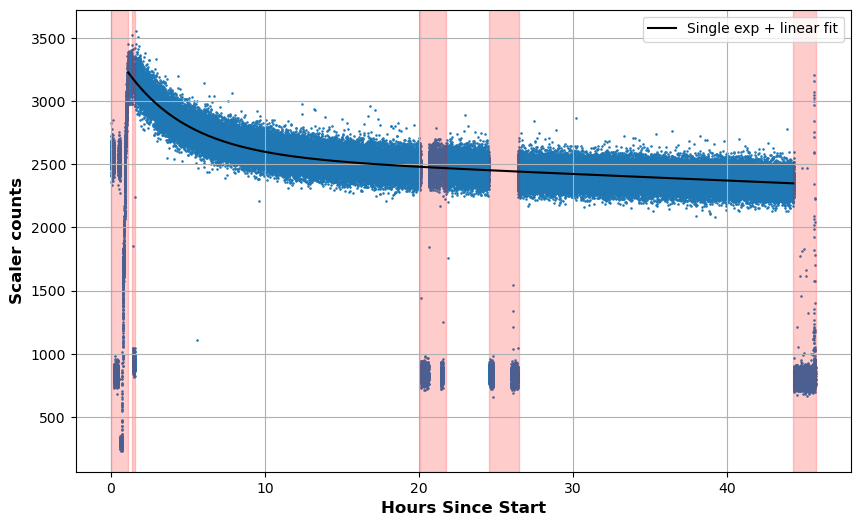

In [25]:
t_fit = np.linspace(t_clean.min(), t_clean.max(), 2000)
y_fit_linear = model_single_exp_linear(t_fit, *popt_linear)

plt.figure(figsize=(10, 6))
plt.plot(t_fit, y_fit_linear, label="Single exp + linear fit", color="k")
plt.scatter(hours_since_start, data[:, 2].astype(float), s=0.7)

plt.axvspan(hours_since_start[0],        hours_since_start[4000],       alpha=0.2, color="red")
plt.axvspan(hours_since_start[5000],     hours_since_start[5700],       alpha=0.2, color="red")
plt.axvspan(hours_since_start[88000],    hours_since_start[90900],      alpha=0.2, color="red")
plt.axvspan(hours_since_start[72000],    hours_since_start[78000],      alpha=0.2, color="red")
plt.axvspan(hours_since_start[n_data-5200], hours_since_start[n_data-1], alpha=0.2, color="red")

plt.xlabel("Hours Since Start", fontweight="bold", fontsize="large")
plt.ylabel("Scaler counts", fontweight="bold", fontsize="large")
plt.legend()
plt.grid(True)
plt.show()

# Background evolution

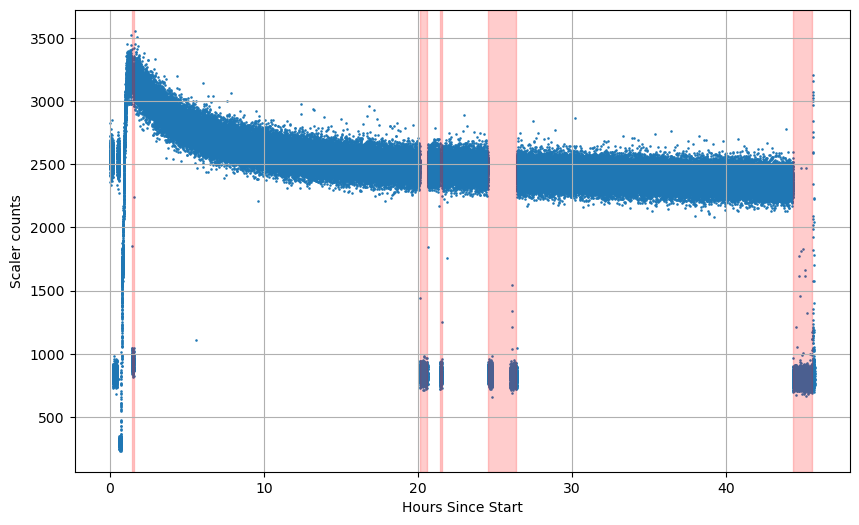

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(hours_since_start, data[:, 2].astype(float), s=0.7, label='Scaler Value')
plt.xlabel('Hours Since Start')
plt.ylabel("Scaler counts")
plt.grid(True)
#plt.xlim(left=42)

plt.axvspan(hours_since_start[5080],hours_since_start[5520],alpha=0.2,color="red")
plt.axvspan(hours_since_start[72200],hours_since_start[74000],alpha=0.2,color="red")
plt.axvspan(hours_since_start[76880],hours_since_start[77320],alpha=0.2,color="red")
plt.axvspan(hours_since_start[88150],hours_since_start[90600],alpha=0.2,color="red")
plt.axvspan(hours_since_start[n_data-5000],hours_since_start[n_data-650],alpha=0.2,color="red")

In [27]:
intervals_bkg = [(5080,5520),(72200,74000),(76880,77320),(88150,90600),(n_data-5000,n_data-650)]

mask_bkg = np.zeros(N, dtype=bool)

for start, end in intervals_bkg:
    mask_bkg[start:end+1] = True

In [28]:
t_clean_bkg = hours_since_start[mask_bkg]
counts_clean_bkg = data[:, 2].astype(float)[mask_bkg]

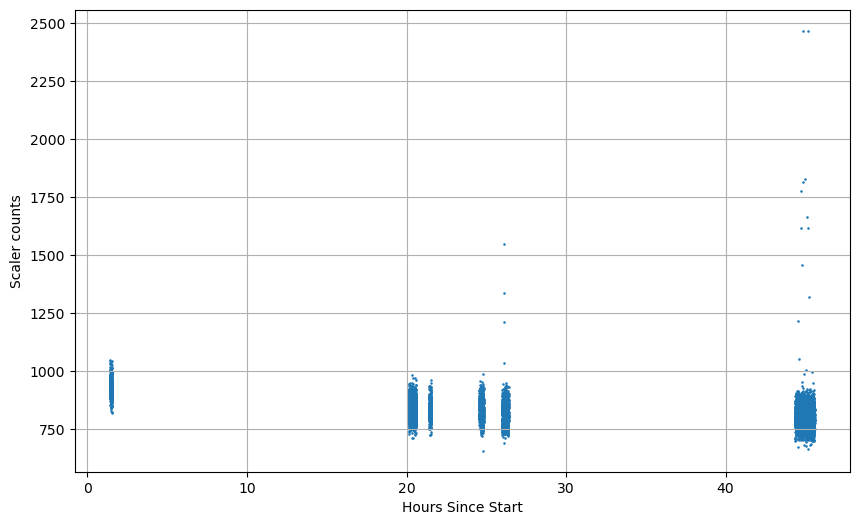

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(t_clean_bkg,counts_clean_bkg, s=0.7, label='Scaler Value')
plt.xlabel('Hours Since Start')
plt.ylabel("Scaler counts")
plt.grid(True)

In [41]:
sigma_bkg = np.sqrt(counts_clean_bkg)  

p0_bkg = [800, 30, 800]  

bounds_bkg = [0, 0, 0], [np.inf, np.inf, np.inf]

popt_bkg, pcov_bkg = curve_fit(model_single_exp, t_clean_bkg,counts_clean_bkg , p0=p0_bkg,sigma=sigma_bkg, absolute_sigma=True)

print("Best-fit params:", popt_bkg)
print("Errors:", np.sqrt(np.diag(pcov_bkg)))

Best-fit params: [152.38291194  16.66688487 792.69905816]
Errors: [1.6807528  0.36866804 0.93249831]


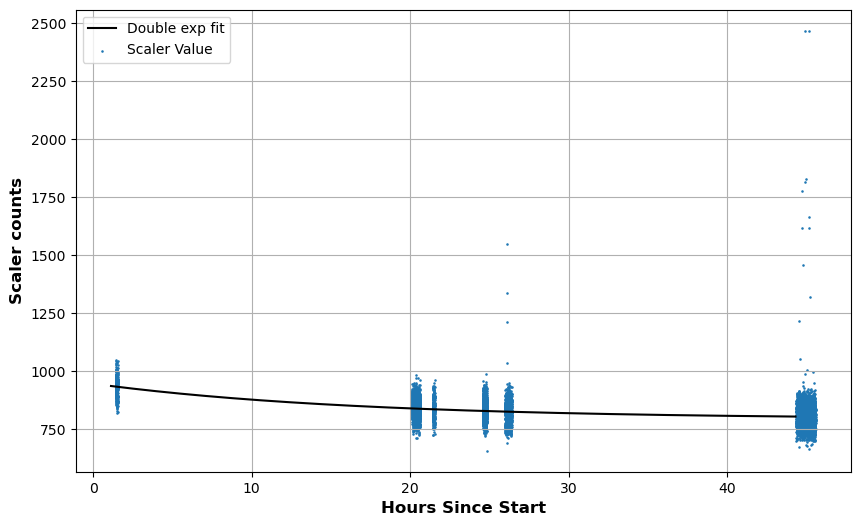

In [42]:
t_fit_bkg = np.linspace(t_clean_bkg.min(), t_clean_bkg.max(), 2000)

y_fit = model_single_exp(t_fit, *popt_bkg)

plt.figure(figsize=(10,6))

plt.plot(t_fit, y_fit, label="Double exp fit",color="k")

plt.xlabel("Hours Since Start",fontweight="bold",fontsize="large")
plt.ylabel("Scaler counts",fontweight="bold",fontsize="large")
plt.grid(True)

plt.scatter(t_clean_bkg,counts_clean_bkg, s=0.7, label='Scaler Value')

plt.legend()



Chi-squared: 25317.0068
Reduced chi-squared: 2.6700


Text(0, 0.5, 'Normalized residuals')

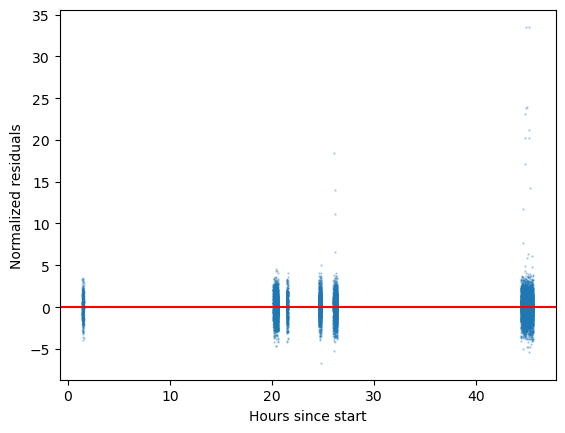

In [43]:
residuals_bkg= (counts_clean_bkg- model_single_exp(t_clean_bkg, *popt_bkg)) / sigma_bkg
chi_squared_bkg = np.sum(residuals_bkg**2)
dof_bkg = len(counts_clean_bkg) - len(popt_bkg)
reduced_chi_sq_bkg = chi_squared_bkg / dof_bkg

print(f"\nChi-squared: {chi_squared_bkg:.4f}")
reduced_chi_sq_bkg = chi_squared_bkg / dof_bkg
print(f"Reduced chi-squared: {reduced_chi_sq_bkg:.4f}")

plt.figure()
plt.scatter(t_clean_bkg, residuals_bkg, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')

In [44]:
p0_bkg_lin = [-1, 2400]

bounds_bkg_lin = ([-np.inf, 0], [0, np.inf])
def model_linear_bg(t, m, c):
    return m * t + c

popt_bkg_lin, pcov_bkg_lin = curve_fit(model_linear_bg, t_clean_bkg, counts_clean_bkg, p0=p0_bkg_lin, sigma=sigma_bkg, absolute_sigma=True, bounds=bounds_bkg_lin)

print("Best-fit params:", popt_bkg_lin)
print("Errors:", np.sqrt(np.diag(pcov_bkg_lin)))


Best-fit params: [ -1.89916471 883.77847317]
Errors: [0.0234214  0.81703238]


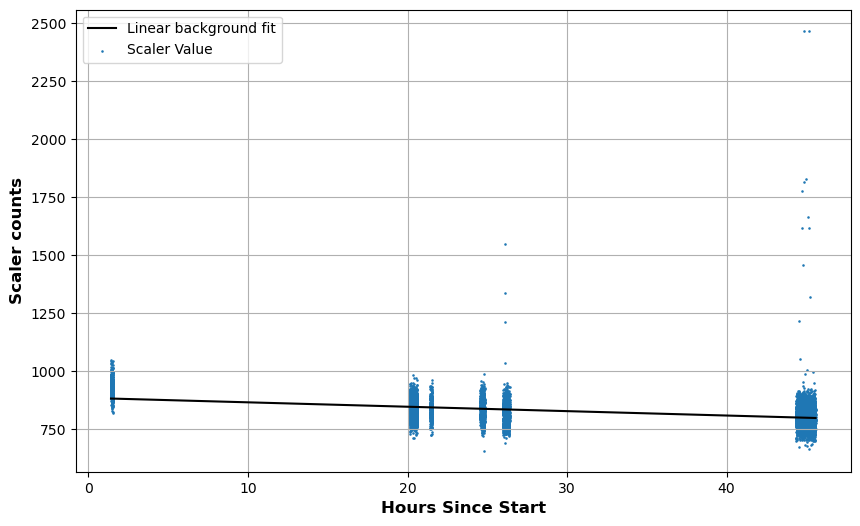

In [34]:
t_fit_bkg_lin = np.linspace(t_clean_bkg.min(), t_clean_bkg.max(), 2000)

y_fit_bkg_lin = model_linear_bg(t_fit_bkg_lin, *popt_bkg_lin)

plt.figure(figsize=(10,6))

plt.plot(t_fit_bkg_lin, y_fit_bkg_lin, label="Linear background fit", color="k")

plt.xlabel("Hours Since Start", fontweight="bold", fontsize="large")
plt.ylabel("Scaler counts", fontweight="bold", fontsize="large")
plt.grid(True)

plt.scatter(t_clean_bkg, counts_clean_bkg, s=0.7, label='Scaler Value')

plt.legend()

In [35]:
residuals_bkg_lin = (counts_clean_bkg - model_linear_bg(t_clean_bkg, *popt_bkg_lin)) / sigma_bkg
chi_squared_bkg_lin = np.sum(residuals_bkg_lin**2)
dof_bkg_lin = len(counts_clean_bkg) - len(popt_bkg_lin)
reduced_chi_sq_bkg_lin = chi_squared_bkg_lin / dof_bkg_lin

print(f"\nChi-squared: {chi_squared_bkg_lin:.4f}")
print(f"Reduced chi-squared: {reduced_chi_sq_bkg_lin:.4f}")
print(f"DOF: {dof_bkg_lin}")


Chi-squared: 27100.3793
Reduced chi-squared: 2.8578
DOF: 9483


Text(0, 0.5, 'Normalized residuals')

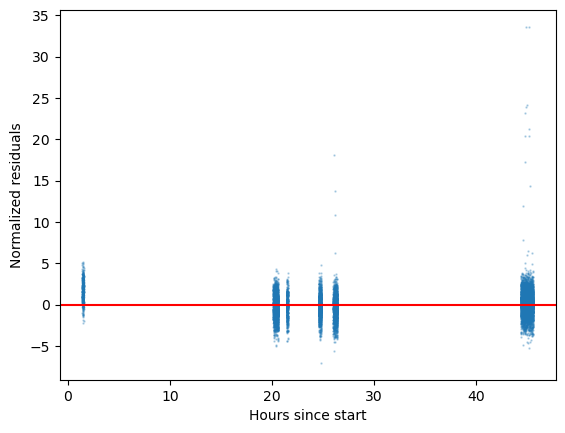

In [36]:

plt.figure()
plt.scatter(t_clean_bkg, residuals_bkg_lin, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')


=== Single exp + linear background ===
Best-fit params: [ 1.35010707e+02  1.43898826e+01 -3.07779107e-01  8.10837127e+02]
Errors: [24.76913019  3.47738072  0.45792506 26.08943065]
Success: True
Message: `ftol` termination condition is satisfied.
Chi-squared: 25316.6477
Reduced chi-squared: 2.6703
DOF: 9481


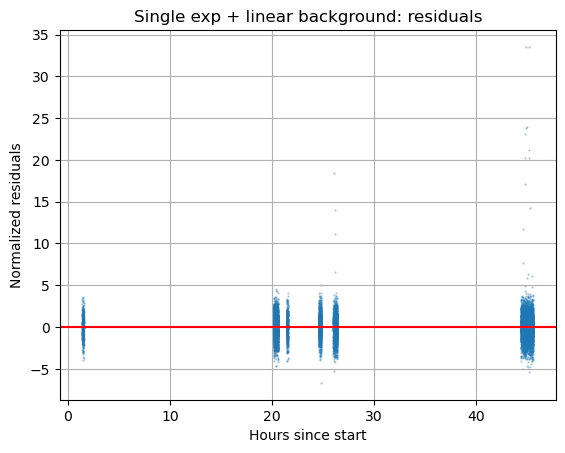

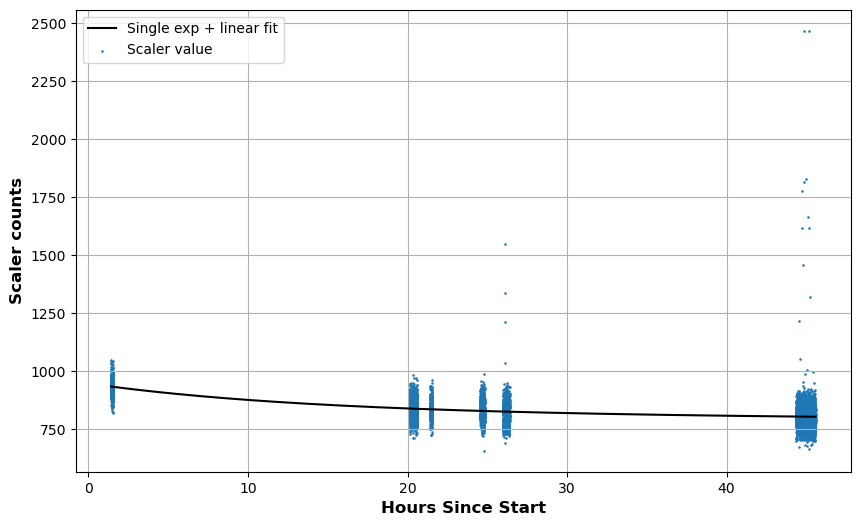

In [37]:
sigma_bkg = np.sqrt(counts_clean_bkg)

p0_bkg_linear = [800, 30, -1, 800]
bounds_bkg_linear = ([0, 0, -np.inf, 0],
                     [np.inf, np.inf, 0, np.inf])

popt_bkg_linear, pcov_bkg_linear, infodict_bkg_linear, mesg_bkg_linear, ier_bkg_linear = curve_fit(
    model_single_exp_linear, t_clean_bkg, counts_clean_bkg,
    p0=p0_bkg_linear, sigma=sigma_bkg, bounds=bounds_bkg_linear,
    absolute_sigma=True, full_output=True)

print("\n=== Single exp + linear background ===")
print("Best-fit params:", popt_bkg_linear)
print("Errors:", np.sqrt(np.diag(pcov_bkg_linear)))
print(f"Success: {ier_bkg_linear in [1, 2, 3, 4]}")
print(f"Message: {mesg_bkg_linear}")

residuals_bkg_linear = (counts_clean_bkg - model_single_exp_linear(t_clean_bkg, *popt_bkg_linear)) / sigma_bkg
chi_squared_bkg_linear = np.sum(residuals_bkg_linear**2)
dof_bkg_linear = len(counts_clean_bkg) - len(popt_bkg_linear)
reduced_chi_sq_bkg_linear = chi_squared_bkg_linear / dof_bkg_linear
print(f"Chi-squared: {chi_squared_bkg_linear:.4f}")
print(f"Reduced chi-squared: {reduced_chi_sq_bkg_linear:.4f}")
print(f"DOF: {dof_bkg_linear}")

plt.figure()
plt.scatter(t_clean_bkg, residuals_bkg_linear, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')
plt.title('Single exp + linear background: residuals')
plt.grid(True)

t_fit_bkg = np.linspace(t_clean_bkg.min(), t_clean_bkg.max(), 2000)
y_fit_bkg_linear = model_single_exp_linear(t_fit_bkg, *popt_bkg_linear)

plt.figure(figsize=(10, 6))
plt.plot(t_fit_bkg, y_fit_bkg_linear, label="Single exp + linear fit", color="k")
plt.scatter(t_clean_bkg, counts_clean_bkg, s=0.7, label='Scaler value')
plt.xlabel("Hours Since Start", fontweight="bold", fontsize="large")
plt.ylabel("Scaler counts", fontweight="bold", fontsize="large")
plt.legend()
plt.grid(True)
plt.show()


=== Double exp + constant (background) ===
Best-fit params: [134.34577054  14.35638723 213.7061972  643.08905593 597.79511033]
Errors: [9.07539681e+02 5.88230097e+01 2.14132711e+05 7.04356325e+05
 2.15047276e+05]
Success: True
Message: `ftol` termination condition is satisfied.
Chi-squared: 25316.6531
Reduced chi-squared: 2.6705
DOF: 9480


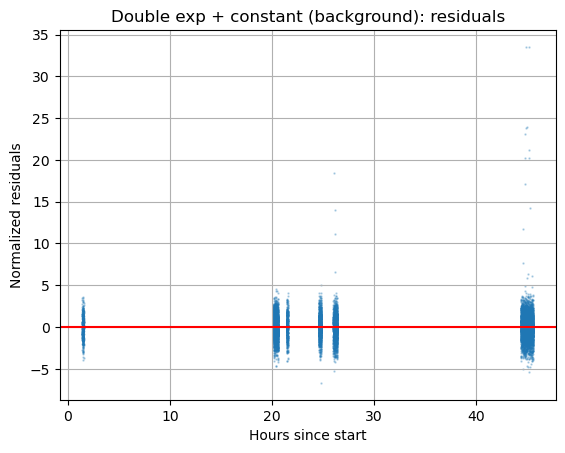

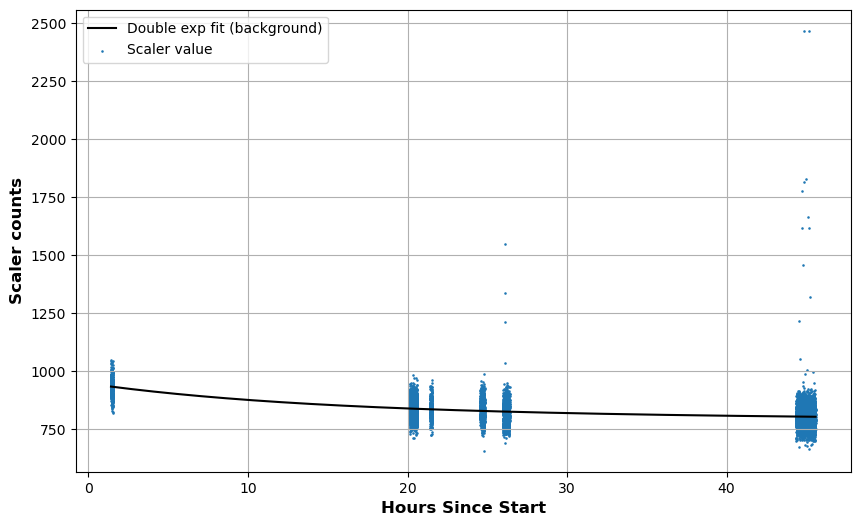

In [38]:
sigma_bkg = np.sqrt(counts_clean_bkg)

p0_bkg = [800, 30, 800, 100, 100]
bounds_bkg = ([0, 0, 0, 0, 0],
              [np.inf, np.inf, np.inf, np.inf, np.inf])

popt_bkg, pcov_bkg, infodict_bkg, mesg_bkg, ier_bkg = curve_fit(
    model, t_clean_bkg, counts_clean_bkg,
    p0=p0_bkg, sigma=sigma_bkg, bounds=bounds_bkg,
    absolute_sigma=True, full_output=True)

print("\n=== Double exp + constant (background) ===")
print("Best-fit params:", popt_bkg)
print("Errors:", np.sqrt(np.diag(pcov_bkg)))
print(f"Success: {ier_bkg in [1, 2, 3, 4]}")
print(f"Message: {mesg_bkg}")

residuals_bkg = (counts_clean_bkg - model(t_clean_bkg, *popt_bkg)) / sigma_bkg
chi_squared_bkg = np.sum(residuals_bkg**2)
dof_bkg = len(counts_clean_bkg) - len(popt_bkg)
reduced_chi_sq_bkg = chi_squared_bkg / dof_bkg
print(f"Chi-squared: {chi_squared_bkg:.4f}")
print(f"Reduced chi-squared: {reduced_chi_sq_bkg:.4f}")
print(f"DOF: {dof_bkg}")

# Residuals plot
plt.figure()
plt.scatter(t_clean_bkg, residuals_bkg, s=0.5, alpha=0.3)
plt.axhline(0, color='r')
plt.xlabel('Hours since start')
plt.ylabel('Normalized residuals')
plt.title('Double exp + constant (background): residuals')
plt.grid(True)

# Fit plot
t_fit_bkg = np.linspace(t_clean_bkg.min(), t_clean_bkg.max(), 2000)
y_fit_bkg = model(t_fit_bkg, *popt_bkg)

plt.figure(figsize=(10, 6))
plt.plot(t_fit_bkg, y_fit_bkg, label="Double exp fit (background)", color="k")
plt.scatter(t_clean_bkg, counts_clean_bkg, s=0.7, label='Scaler value')
plt.xlabel("Hours Since Start", fontweight="bold", fontsize="large")
plt.ylabel("Scaler counts", fontweight="bold", fontsize="large")
plt.legend()
plt.grid(True)
plt.show()

# Calculating efficiencies

0.5513287429592744


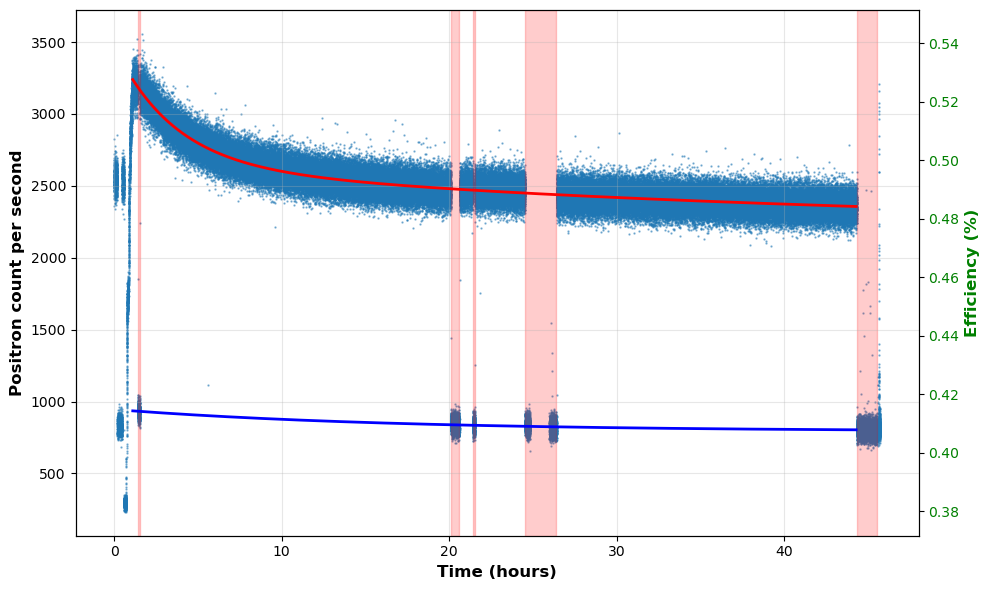

In [47]:
# Generate fitted curves
t_fit = np.linspace(t_clean.min(), t_clean.max(), 1000)
y_fit = model(t_fit, *popt)
y_fit_bkg = model_single_exp(t_fit, *popt_bkg)

# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot full dataset on left axis
ax1.scatter(hours_since_start, data[:, 2].astype(float), s=0.5, alpha=0.5, label='Full data')
ax1.plot(t_fit, y_fit, 'r-', linewidth=2, label='Fit (t_clean)')
ax1.plot(t_fit, y_fit_bkg, 'b-', linewidth=2, label='Fit (bkg)')
ax1.set_xlabel('Time (hours)',fontweight="bold",fontsize="large")
ax1.set_ylabel('Positron count per second',fontweight="bold",fontsize="large")
ax1.tick_params(axis='y', labelcolor='k')

intervals_final = [(5080,5520),(72200,74000),(76880,77320),(88150,90600),(n_data-5000,n_data-650)]
# Add axvspan regions for cut intervals
for start, end in intervals_final:
    ax1.axvspan(hours_since_start[start], hours_since_start[end], 
                alpha=0.2, color='red', label='Cut regions' if start == intervals[0][0] else '')

# Create right y-axis for efficiency (no plot, just axis)
ax2 = ax1.twinx()
efficiency = (y_fit - y_fit_bkg) * (67*100/28e6)
print(np.max(efficiency))

ax2.set_ylabel('Efficiency (%)', color='g',fontweight="bold",fontsize="large")
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim([efficiency.min(), efficiency.max()])


ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# During regrow pressure and temperature

In [ ]:
pressure_data1 = np.loadtxt(r"C:\Users\keert\Master Thesis February\Moderator lifetime\Pressure_log_files\Pressure_2026-02-23_14-33-57.log",dtype=str,delimiter=",",usecols=(0,1,2))
pressure_data2 = np.loadtxt(r"C:\Users\keert\Master Thesis February\Moderator lifetime\Pressure_log_files\Pressure_2026-02-24_16-33-28.log",dtype=str,delimiter=",",usecols=(0,1,2))
pressure_data = np.concatenate((pressure_data1, pressure_data2), axis=0)


In [ ]:
print(pressure_data.shape)

pressure_timestamps = np.array([datetime.fromtimestamp(ts) for ts in pressure_data[:, 0].astype(float)])
mod_pressure = pressure_data[:,1].astype(float)
inlet_pressure = pressure_data[:,2].astype(float)

hours_since_start_pressure = np.array([(t - timestamps[0]).total_seconds() / 3600 for t in timestamps])

(535280, 3)


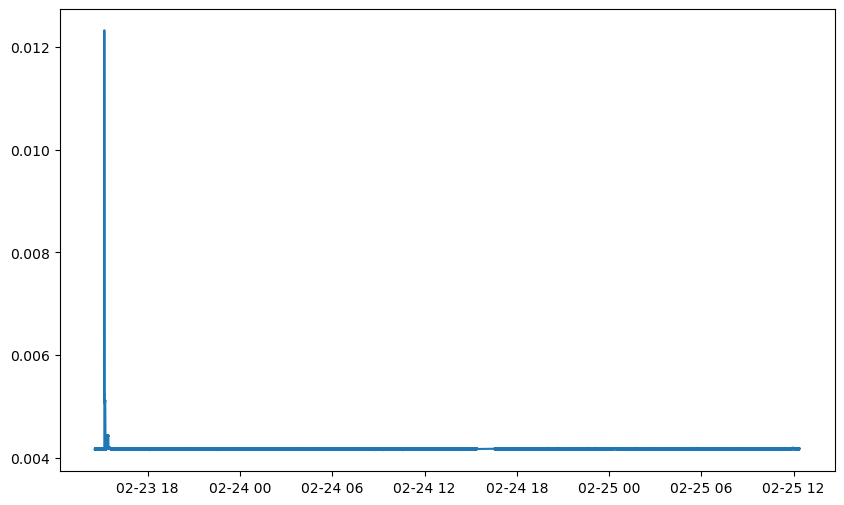

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(pressure_timestamps,mod_pressure, label='Pressure')

In [ ]:
temp_data1 = np.loadtxt(r"C:\Users\keert\Master Thesis February\Moderator lifetime\Temp_log_files\Temp_2026-02-23_14-34-08.log",dtype=str,delimiter=",",usecols=(0,1,2))
temp_data2 = np.loadtxt(r"C:\Users\keert\Master Thesis February\Moderator lifetime\Temp_log_files\Temp_2026-02-24_16-34-07.log",dtype=str,delimiter=",",usecols=(0,1,2))
temp_data = np.concatenate((temp_data1, temp_data2), axis=0)


In [ ]:
print(temp_data.shape)

temp_timestamps = np.array([datetime.fromtimestamp(ts) for ts in temp_data[:, 0].astype(float)])
mod_temp = temp_data[:,1].astype(float)
inlet_temp = temp_data[:,2].astype(float)

hours_since_start_temp = np.array([(t - timestamps[0]).total_seconds() / 3600 for t in timestamps])

(703362, 3)


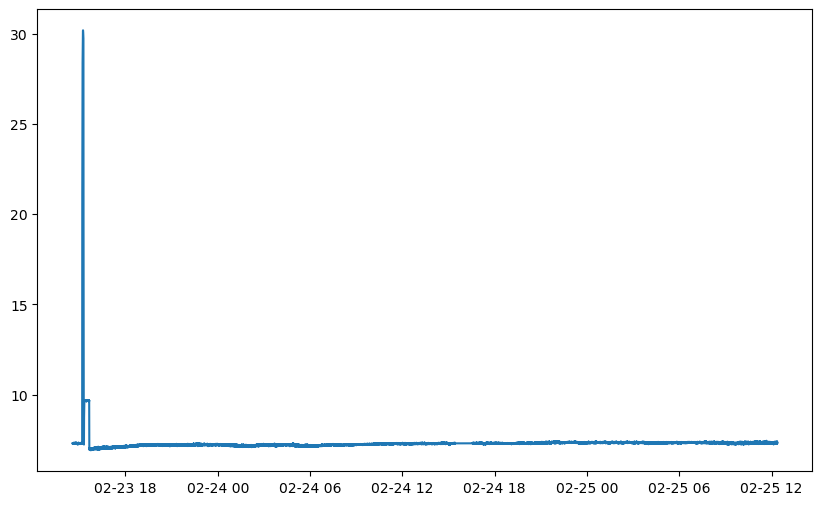

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(temp_timestamps,mod_temp, label='Pressure')

Text(0, 0.5, 'Moderator Temperature (K)')

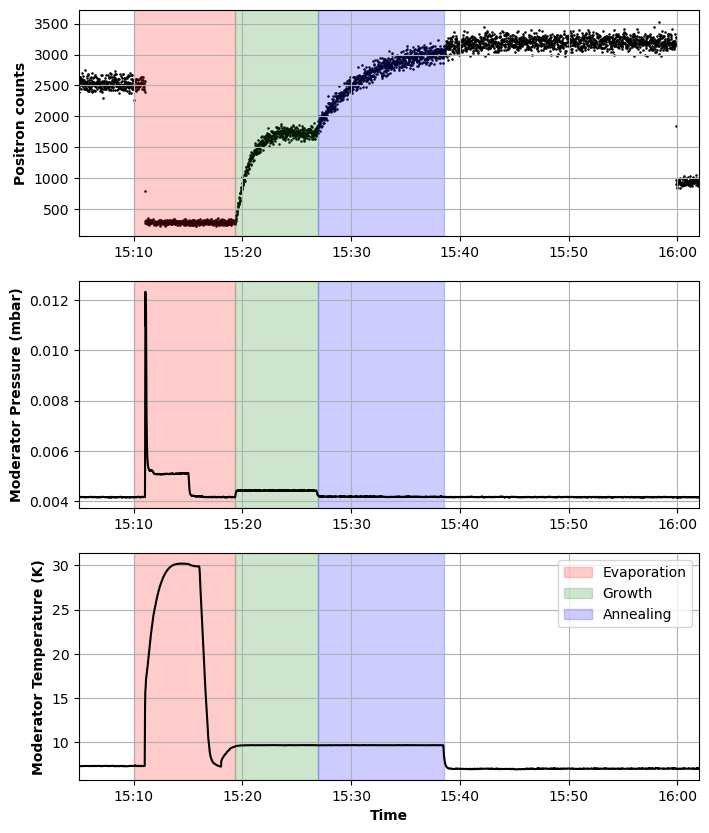

In [ ]:
fig, ax = plt.subplots(3,1,figsize=(8, 10),sharex=True)

time_fmt = mdates.DateFormatter("%H:%M")


ax[0].scatter(timestamps, data[:, 2].astype(float), s=0.7, label='Scaler Value',color="k")
ax[1].plot(pressure_timestamps, mod_pressure,color="k")
ax[2].plot(temp_timestamps, mod_temp,color="k")

start = datetime(2026, 2, 23, 15, 5)
end   = datetime(2026, 2, 23, 16, 2)
ax[2].set_xlim(start,end)

ax[2].xaxis.set_major_formatter(time_fmt)

for x in ax:
    x.tick_params(axis="x", labelbottom=True)
    x.axvspan(datetime(2026, 2, 23, 15, 10), datetime(2026, 2, 23, 15, 19,20), alpha=0.2, color="r",label="Evaporation")
    x.axvspan(datetime(2026, 2, 23, 15, 19,20), datetime(2026, 2, 23, 15, 27), alpha=0.2,color="g", label="Growth")
    x.axvspan(datetime(2026, 2, 23, 15, 27), datetime(2026, 2, 23, 15, 38,30), alpha=0.2,color="b", label="Annealing")
    
    x.grid(True)

ax[2].legend(loc="upper right")

ax[2].set_xlabel("Time",fontweight="bold",fontsize="medium")
ax[0].set_ylabel("Positron counts",fontweight="bold",fontsize="medium")
ax[1].set_ylabel("Moderator Pressure (mbar)",fontweight="bold",fontsize="medium")
ax[2].set_ylabel("Moderator Temperature (K)",fontweight="bold",fontsize="medium")

